# Principal Component Analysis (PCA) on MNIST
### Implementation from scratch and the impact of the number of principal components

**What this notebook covers**

1. Load and prepare MNIST (28×28 digits → 784-dimensional vectors)
2. Implement PCA **from scratch** (centering → SVD → projection) and verify it against `scikit-learn`
3. Variance analysis: explained-variance ratio, scree plot, cumulative variance, components needed for 90/95/99 %
4. Visualise the mean image and the principal axes ("eigen-digits")
5. **Impact of varying the number of components** on:
   - reconstruction quality (MSE, PSNR, visual comparison)
   - 2-D / 3-D embeddings
   - downstream classification accuracy (KNN and logistic regression) and training time
6. Bonus: PCA as a denoiser — how many components is "just right"?
7. Summary table and conclusions

**Maths recap.** Given centred data $X_c \in \mathbb{R}^{n\times d}$, the SVD $X_c = U\Sigma V^\top$ gives the principal axes as the rows of $V^\top$, and the variance along axis $i$ is $\lambda_i = \sigma_i^2/(n-1)$. Projecting on the top $k$ axes gives $Z = X_c V_k$ and the reconstruction $\hat X = Z V_k^\top + \mu$.

## 1. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3-D projection)

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA as SkPCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [3]:
import ssl, certifi
ssl._create_default_https_context = lambda *a, **k: ssl.create_default_context(cafile=certifi.where())

## 2. Load and prepare MNIST

We use a random 20,000-image subset of the 70,000 MNIST images so that every experiment (especially the classifiers) runs in a reasonable time. Pixels are scaled to $[0,1]$. Increase `N_SAMPLES` to `70000` for the full dataset.

In [4]:
N_SAMPLES = 20_000

mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_all = mnist.data.astype(np.float32) / 255.0
y_all = mnist.target.astype(int)

rng = np.random.RandomState(SEED)
idx = rng.choice(len(X_all), N_SAMPLES, replace=False)
X, y = X_all[idx], y_all[idx]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Pixel range:", X_train.min(), "-", X_train.max())

Train: (16000, 784)  Test: (4000, 784)
Pixel range: 0.0 - 1.0


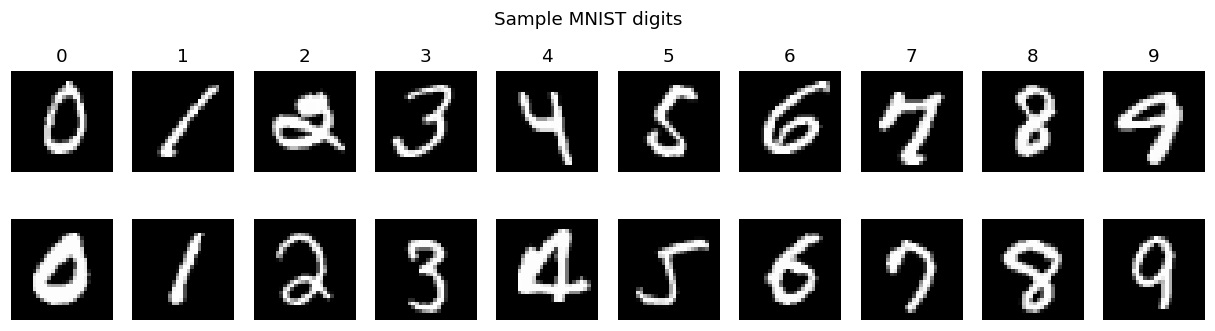

In [5]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for d, ax in enumerate(axes.T):
    ids = np.where(y_train == d)[0][:2]
    for a, i in zip(ax, ids):
        a.imshow(X_train[i].reshape(28, 28), cmap="gray"); a.axis("off")
    ax[0].set_title(str(d))
plt.suptitle("Sample MNIST digits", y=1.02); plt.show()

## 3. PCA from scratch

The class below fits **all** components once (via SVD of the centred training data). Because the components are ordered by variance, we can then evaluate *any* number of components $k$ by slicing, without refitting — ideal for the sweep in section 6.

SVD is numerically more stable than forming the $784\times784$ covariance matrix and eigendecomposing it, but both give the same axes.

In [6]:
class MyPCA:
    """PCA implemented with NumPy SVD. Fit once, then reuse for any k."""

    def fit(self, X):
        n, d = X.shape
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

        # deterministic sign convention: largest-magnitude loading is positive
        max_idx = np.argmax(np.abs(Vt), axis=1)
        Vt *= np.sign(Vt[np.arange(Vt.shape[0]), max_idx])[:, None]

        self.components_ = Vt                              # (d, d): rows = principal axes
        self.eigenvalues_ = (S ** 2) / (n - 1)             # variance along each axis
        self.explained_variance_ratio_ = self.eigenvalues_ / self.eigenvalues_.sum()
        self.cum_var_ = np.cumsum(self.explained_variance_ratio_)
        return self

    def transform(self, X, k=None):
        k = k or self.components_.shape[0]
        return (X - self.mean_) @ self.components_[:k].T

    def inverse_transform(self, Z, k=None):
        k = k or Z.shape[1]
        return Z[:, :k] @ self.components_[:k] + self.mean_


t0 = time.time()
pca = MyPCA().fit(X_train)
print(f"Fitted in {time.time() - t0:.2f}s | components: {pca.components_.shape}")

Fitted in 1.19s | components: (784, 784)


### 3.1 Sanity check against scikit-learn

In [7]:
sk = SkPCA(n_components=50, svd_solver="full").fit(X_train)

print("Max |diff| of explained-variance ratio (first 50):",
      np.abs(pca.explained_variance_ratio_[:50] - sk.explained_variance_ratio_).max())

# components agree up to sign -> |cosine similarity| should be ~1
cos = np.abs(np.sum(pca.components_[:50] * sk.components_, axis=1))
print("Min |cos| between our axes and sklearn's (first 50):", cos.min().round(6))

Z_ours = pca.transform(X_test, 50)
Z_sk = sk.transform(X_test)
print("Projection match (abs):", np.allclose(np.abs(Z_ours), np.abs(Z_sk), atol=1e-3))

Max |diff| of explained-variance ratio (first 50): 4.8428774e-08
Min |cos| between our axes and sklearn's (first 50): 1.0
Projection match (abs): True


## 4. Variance analysis

How much of the data's variance does each component capture, and how many components do we need to keep a given fraction of it?

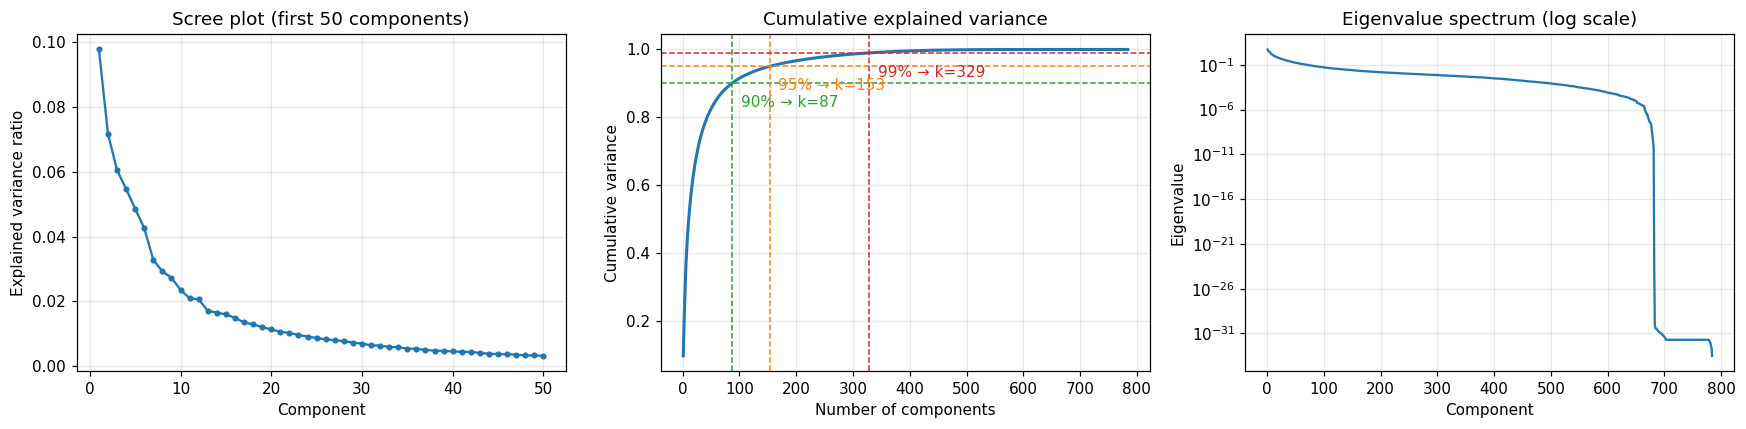

,Variance retained,Components needed,% of 784 dims
0,80%,43,5.5
1,90%,87,11.1
2,95%,153,19.5
3,99%,329,42.0


In [8]:
evr, cum = pca.explained_variance_ratio_, pca.cum_var_

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(range(1, 51), evr[:50], "o-", ms=3)
ax[0].set(title="Scree plot (first 50 components)", xlabel="Component", ylabel="Explained variance ratio")

ax[1].plot(range(1, len(cum) + 1), cum, lw=2)
for t, c in zip([0.90, 0.95, 0.99], ["tab:green", "tab:orange", "tab:red"]):
    k = int(np.searchsorted(cum, t) + 1)
    ax[1].axhline(t, color=c, ls="--", lw=1)
    ax[1].axvline(k, color=c, ls="--", lw=1)
    ax[1].annotate(f"{int(t*100)}% → k={k}", (k, t), xytext=(k + 15, t - 0.07), color=c)
ax[1].set(title="Cumulative explained variance", xlabel="Number of components", ylabel="Cumulative variance")

ax[2].semilogy(range(1, len(evr) + 1), pca.eigenvalues_)
ax[2].set(title="Eigenvalue spectrum (log scale)", xlabel="Component", ylabel="Eigenvalue")
plt.tight_layout(); plt.show()

thr = pd.DataFrame({
    "Variance retained": ["80%", "90%", "95%", "99%"],
    "Components needed": [int(np.searchsorted(cum, t) + 1) for t in [0.8, 0.9, 0.95, 0.99]],
})
thr["% of 784 dims"] = (thr["Components needed"] / 784 * 100).round(1)
thr

## 5. What do the components look like?

The mean image is the "centre" of the dataset; each principal axis is a pattern of pixels that varies jointly. The first few capture coarse structure (e.g. thick vs thin strokes, "0-ness" vs "1-ness"); later ones capture fine detail and eventually noise.

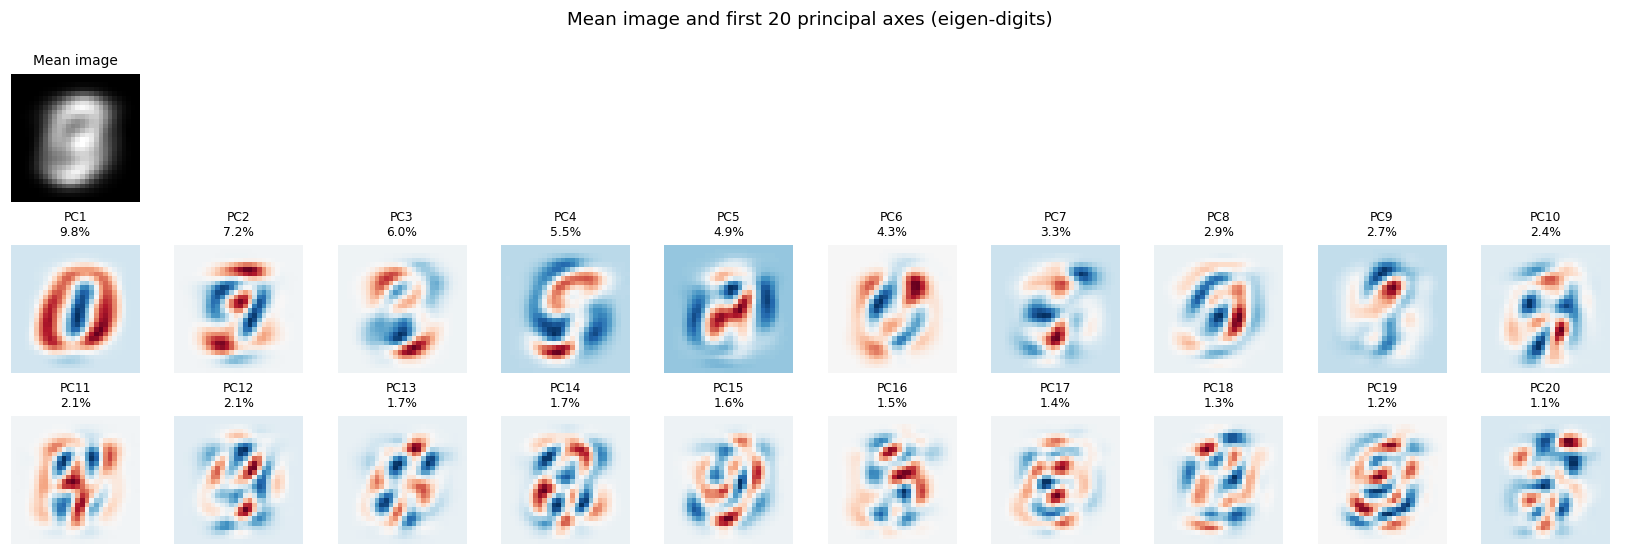

In [9]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for a in axes[0]: a.axis("off")
axes[0, 0].imshow(pca.mean_.reshape(28, 28), cmap="gray")
axes[0, 0].set_title("Mean image", fontsize=9)

for i, ax in enumerate(axes[1:].ravel()):
    ax.imshow(pca.components_[i].reshape(28, 28), cmap="RdBu_r")
    ax.set_title(f"PC{i+1}\n{evr[i]*100:.1f}%", fontsize=8); ax.axis("off")
plt.suptitle("Mean image and first 20 principal axes (eigen-digits)", y=1.0); plt.tight_layout(); plt.show()

## 6. Impact of the number of principal components

### 6.1 Reconstruction quality

For each $k$ we project the **test** set onto $k$ axes (learned from the training set) and reconstruct. We report

- **MSE** = mean squared pixel error
- **PSNR** = $10\log_{10}(1/\text{MSE})$ dB (pixel range is 1) — higher is better
- **Variance retained** (training-set cumulative ratio)
- **Compression ratio** = $784/k$

In [10]:
ks = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 75, 100, 150, 200, 300, 400, 600, 784]

rows = []
for k in ks:
    Xr = pca.inverse_transform(pca.transform(X_test, k), k)
    mse = np.mean((X_test - Xr) ** 2)
    rows.append(dict(k=k, mse=mse, psnr=10 * np.log10(1 / (mse + 1e-12)),
                     var_retained=cum[k - 1], compression=784 / k))
rec = pd.DataFrame(rows)
rec.round(5)

,k,mse,psnr,var_retained,compression
0,1,0.06048,12.184000,0.09757,784.00000
1,2,0.05569,12.542080,0.16914,392.00000
2,3,0.05155,12.877580,0.22957,261.33333
3,5,0.04466,13.501210,0.33278,156.80000
4,10,0.03417,14.663480,0.48826,78.40000
5,15,0.02808,15.515260,0.57961,52.26667
6,20,0.02382,16.230431,0.64461,39.20000
7,30,0.01801,17.444651,0.73190,26.13333
8,40,0.01432,18.440741,0.78709,19.60000
9,50,0.01176,19.296619,0.82545,15.68000


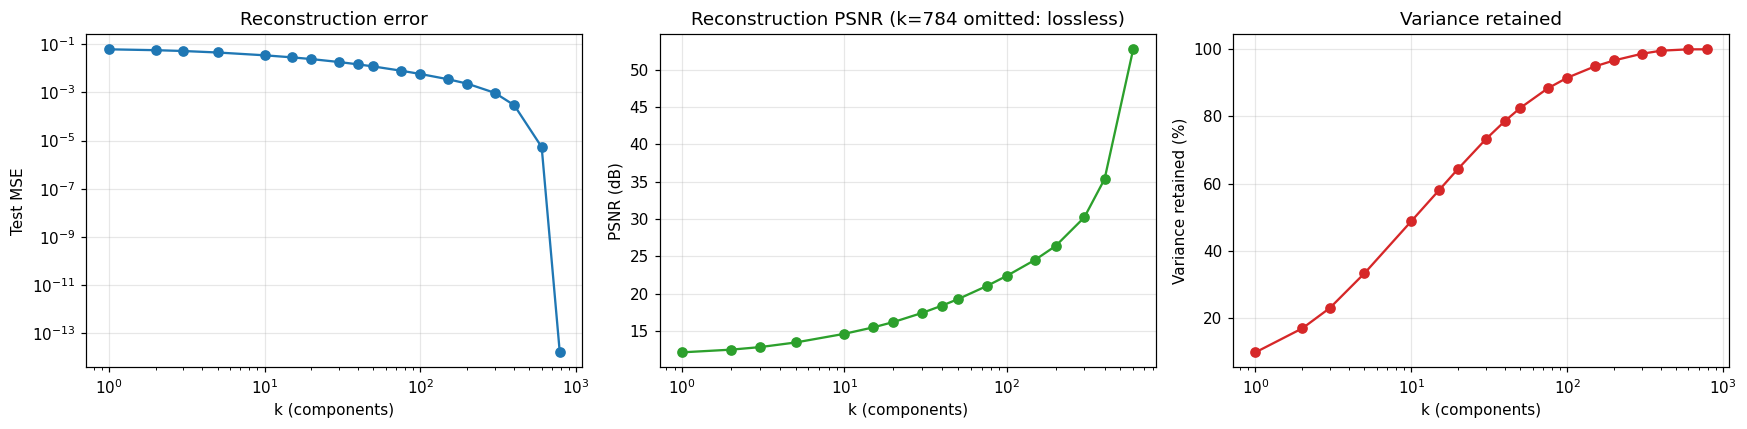

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(rec.k, rec.mse, "o-"); ax[0].set(xscale="log", yscale="log", xlabel="k (components)", ylabel="Test MSE", title="Reconstruction error")
ax[1].plot(rec.k[:-1], rec.psnr[:-1], "o-", color="tab:green"); ax[1].set(xscale="log", xlabel="k (components)", ylabel="PSNR (dB)", title="Reconstruction PSNR (k=784 omitted: lossless)")
ax[2].plot(rec.k, rec.var_retained * 100, "o-", color="tab:red"); ax[2].set(xscale="log", xlabel="k (components)", ylabel="Variance retained (%)", title="Variance retained")
plt.tight_layout(); plt.show()

### 6.2 Visual reconstructions

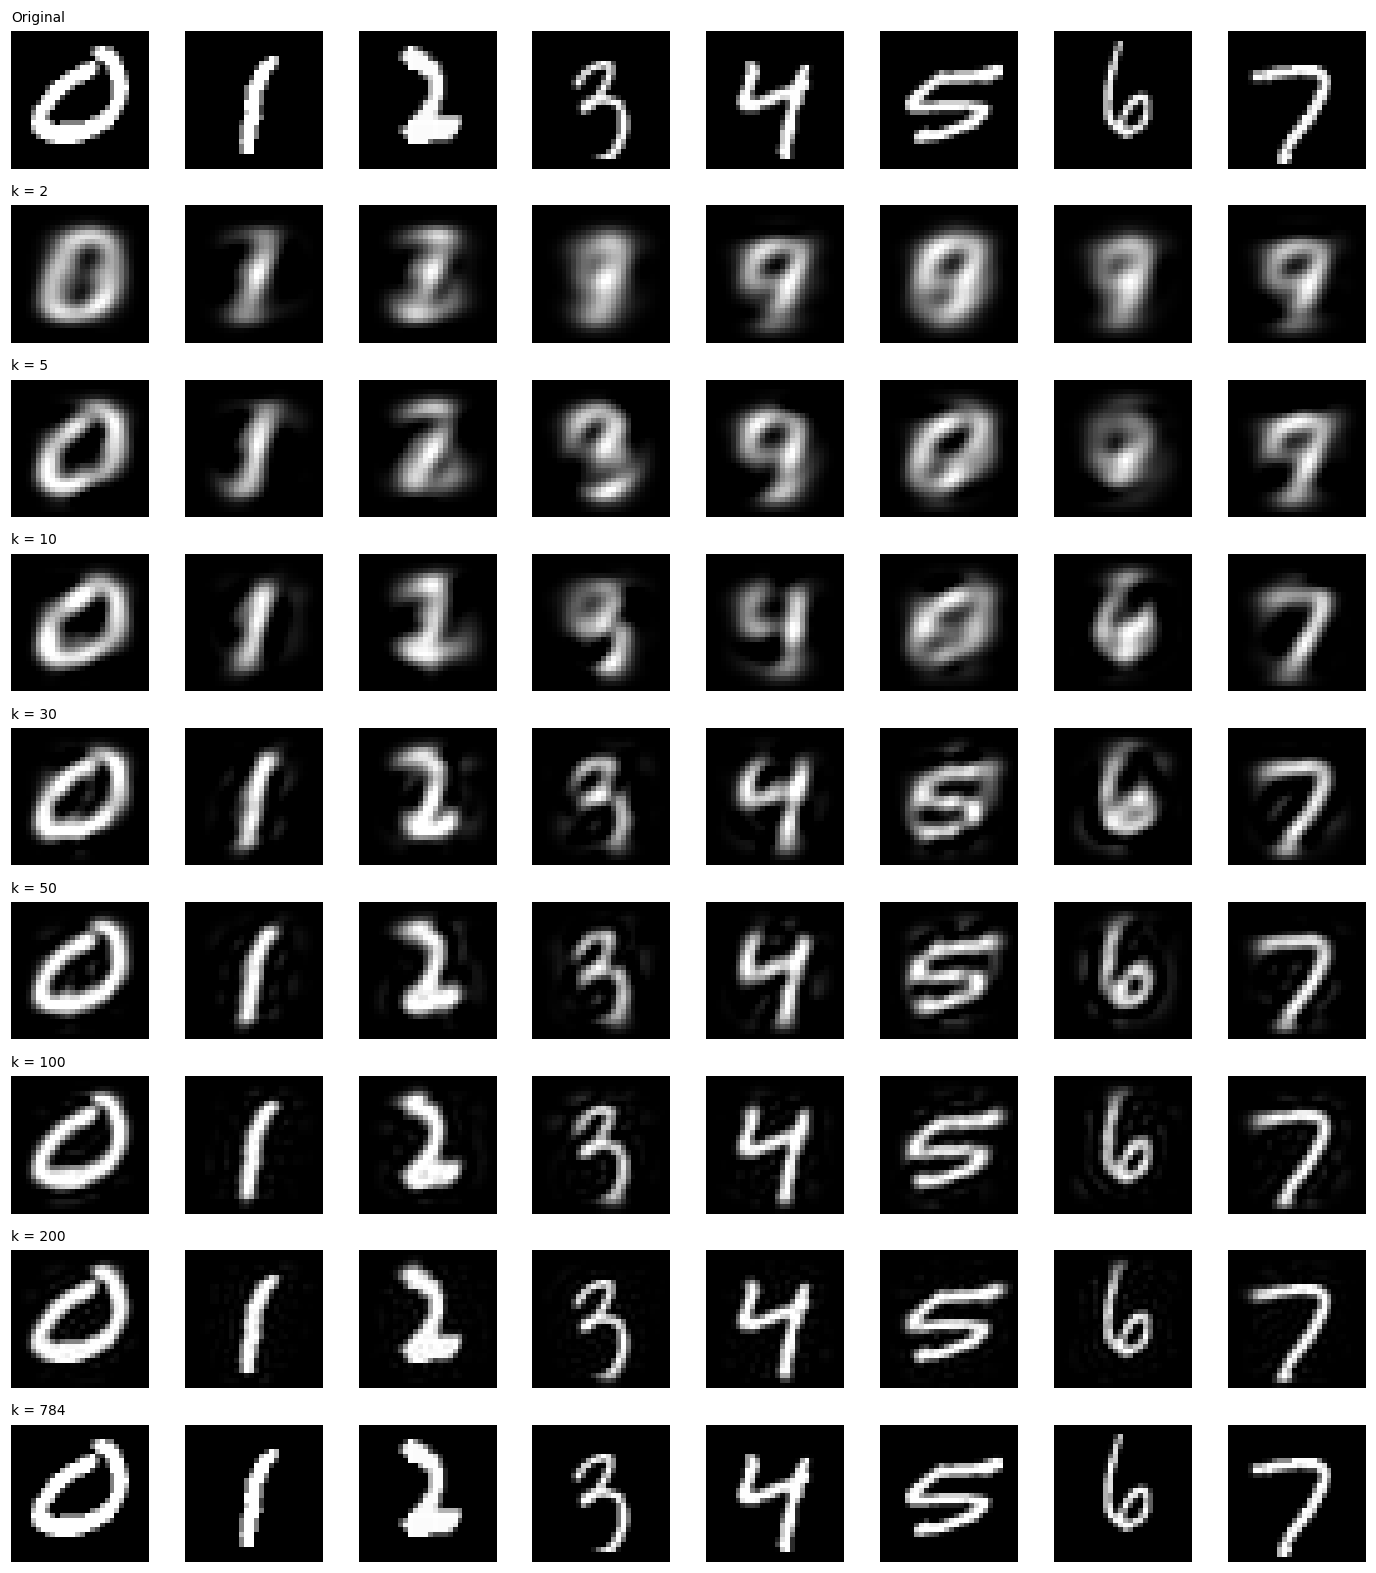

In [12]:
show_k = [2, 5, 10, 30, 50, 100, 200, 784]
n_show = 8
sel = np.array([np.where(y_test == d)[0][0] for d in range(n_show)])

fig, axes = plt.subplots(len(show_k) + 1, n_show, figsize=(1.6 * n_show, 1.6 * (len(show_k) + 1)))
for j, i in enumerate(sel):
    axes[0, j].imshow(X_test[i].reshape(28, 28), cmap="gray"); axes[0, j].axis("off")
axes[0, 0].set_title("Original", loc="left", fontsize=9)
for r, k in enumerate(show_k, start=1):
    Xr = pca.inverse_transform(pca.transform(X_test[sel], k), k)
    for j in range(n_show):
        axes[r, j].imshow(np.clip(Xr[j], 0, 1).reshape(28, 28), cmap="gray"); axes[r, j].axis("off")
    axes[r, 0].set_title(f"k = {k}", loc="left", fontsize=9)
plt.tight_layout(); plt.show()

### 6.3 Low-dimensional embeddings (k = 2 and k = 3)

With only 2–3 components the digit classes already form recognisable (but overlapping) clusters.

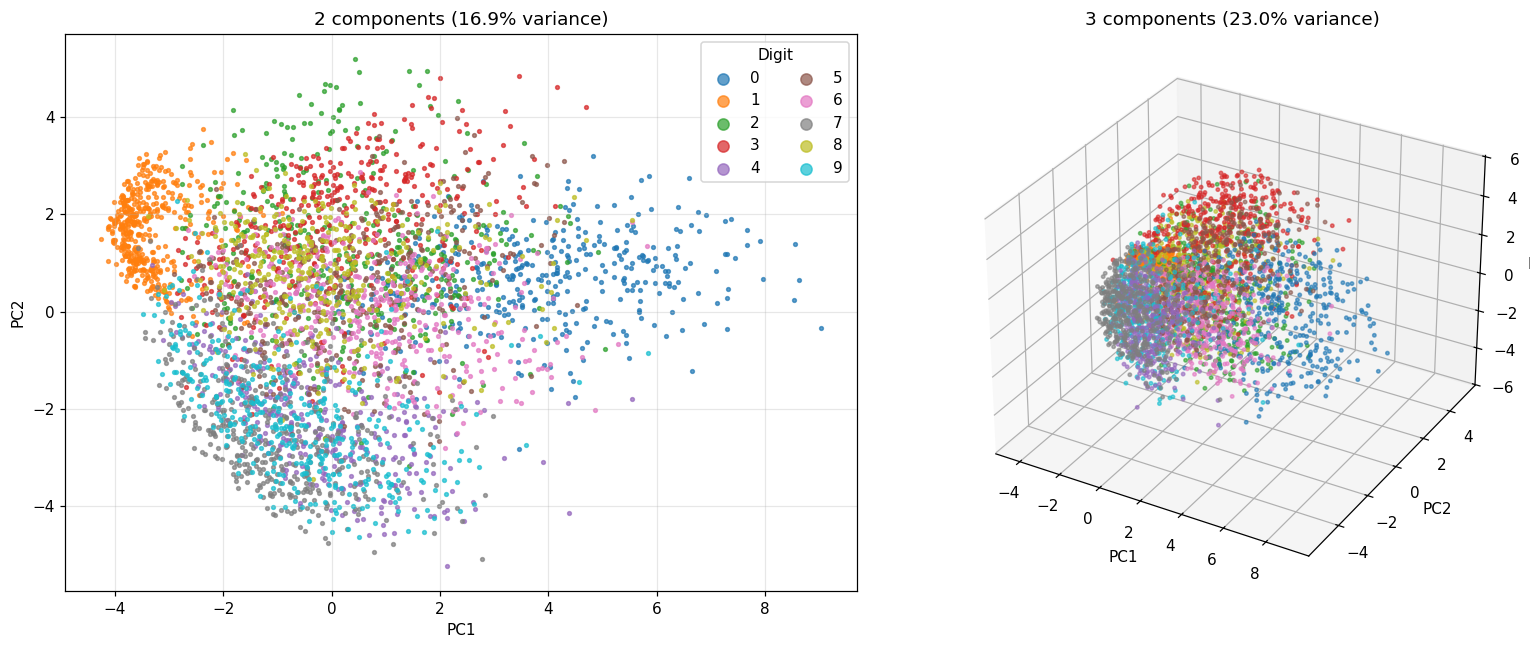

In [13]:
Z2 = pca.transform(X_test, 2)
Z3 = pca.transform(X_test, 3)
cmap = plt.get_cmap("tab10")

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1)
for d in range(10):
    m = y_test == d
    ax1.scatter(Z2[m, 0], Z2[m, 1], s=6, color=cmap(d), label=str(d), alpha=0.7)
ax1.set(xlabel="PC1", ylabel="PC2", title=f"2 components ({cum[1]*100:.1f}% variance)")
ax1.legend(markerscale=3, ncol=2, title="Digit")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for d in range(10):
    m = y_test == d
    ax2.scatter(Z3[m, 0], Z3[m, 1], Z3[m, 2], s=5, color=cmap(d), alpha=0.6)
ax2.set(xlabel="PC1", ylabel="PC2", zlabel="PC3", title=f"3 components ({cum[2]*100:.1f}% variance)")
plt.tight_layout(); plt.show()

### 6.4 Downstream classification vs number of components

Does throwing away dimensions hurt a classifier? We train on the PCA-projected training set and test on the PCA-projected test set, recording accuracy and training time. `k = 784` is the no-reduction baseline.

In [14]:
ks_clf = [2, 5, 10, 20, 30, 50, 100, 200, 784]
clf_rows = []
for k in ks_clf:
    Ztr, Zte = pca.transform(X_train, k), pca.transform(X_test, k)

    t0 = time.time()
    knn = KNeighborsClassifier(n_neighbors=5).fit(Ztr, y_train)
    knn_acc = knn.score(Zte, y_test)
    knn_t = time.time() - t0

    t0 = time.time()
    lr = LogisticRegression(max_iter=300).fit(Ztr, y_train)
    lr_acc = lr.score(Zte, y_test)
    lr_t = time.time() - t0

    clf_rows.append(dict(k=k, knn_acc=knn_acc, knn_time_s=knn_t, logreg_acc=lr_acc, logreg_time_s=lr_t))
    print(f"k={k:>3} | KNN {knn_acc:.4f} ({knn_t:5.1f}s) | LogReg {lr_acc:.4f} ({lr_t:5.1f}s)")
clf = pd.DataFrame(clf_rows)

k=  2 | KNN 0.4143 (  0.1s) | LogReg 0.4392 (  0.2s)
k=  5 | KNN 0.7382 (  0.1s) | LogReg 0.6773 (  0.2s)
k= 10 | KNN 0.9090 (  0.3s) | LogReg 0.8030 (  0.2s)
k= 20 | KNN 0.9540 (  4.7s) | LogReg 0.8700 (  0.2s)
k= 30 | KNN 0.9597 (  0.1s) | LogReg 0.8870 (  0.3s)
k= 50 | KNN 0.9620 (  0.1s) | LogReg 0.9000 (  0.3s)
k=100 | KNN 0.9575 (  0.1s) | LogReg 0.9067 (  0.4s)
k=200 | KNN 0.9525 (  0.2s) | LogReg 0.9100 (  0.6s)
k=784 | KNN 0.9520 (  0.6s) | LogReg 0.9038 (  1.7s)


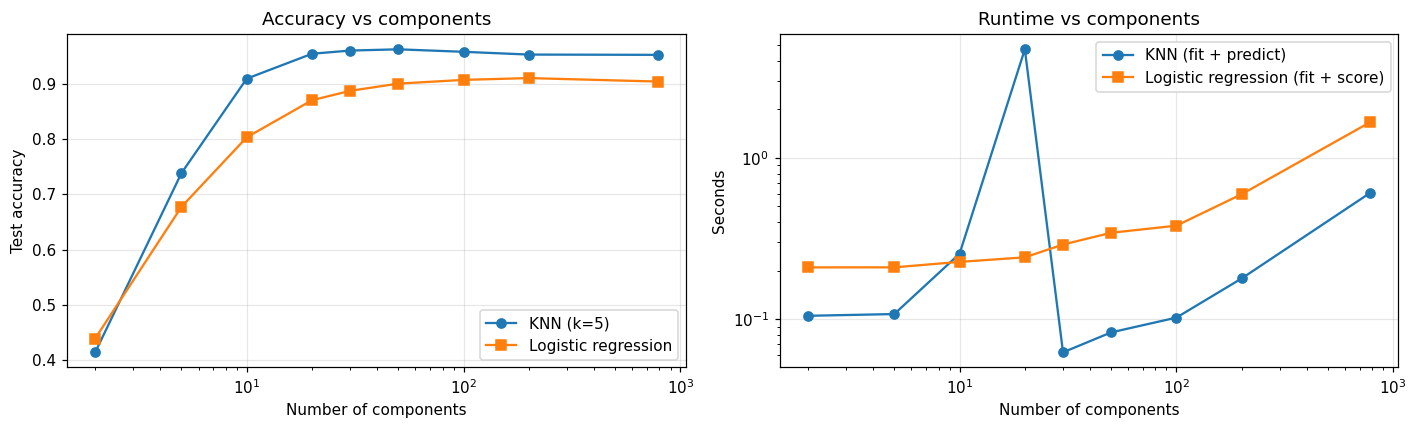

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(clf.k, clf.knn_acc, "o-", label="KNN (k=5)")
ax[0].plot(clf.k, clf.logreg_acc, "s-", label="Logistic regression")
ax[0].set(xscale="log", xlabel="Number of components", ylabel="Test accuracy", title="Accuracy vs components"); ax[0].legend()

ax[1].plot(clf.k, clf.knn_time_s, "o-", label="KNN (fit + predict)")
ax[1].plot(clf.k, clf.logreg_time_s, "s-", label="Logistic regression (fit + score)")
ax[1].set(xscale="log", yscale="log", xlabel="Number of components", ylabel="Seconds", title="Runtime vs components"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Bonus: PCA as a denoiser

If the signal lives in a low-dimensional subspace while Gaussian noise spreads across *all* 784 directions, projecting onto the top $k$ axes removes most of the noise. Too few components throw away signal; too many keep the noise. We add Gaussian noise ($\sigma=0.3$) to the test images and look for the best $k$.

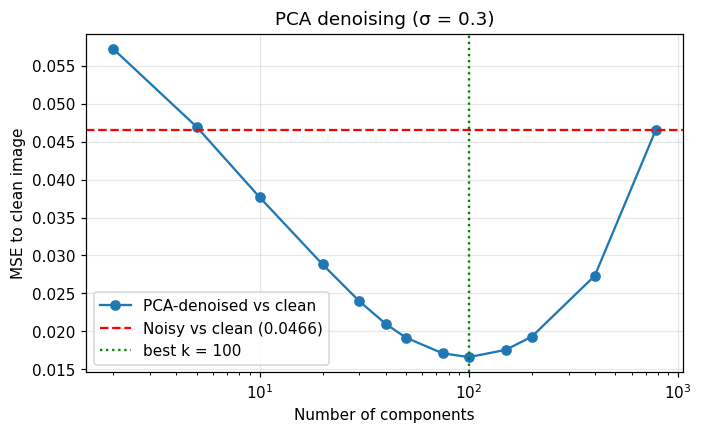

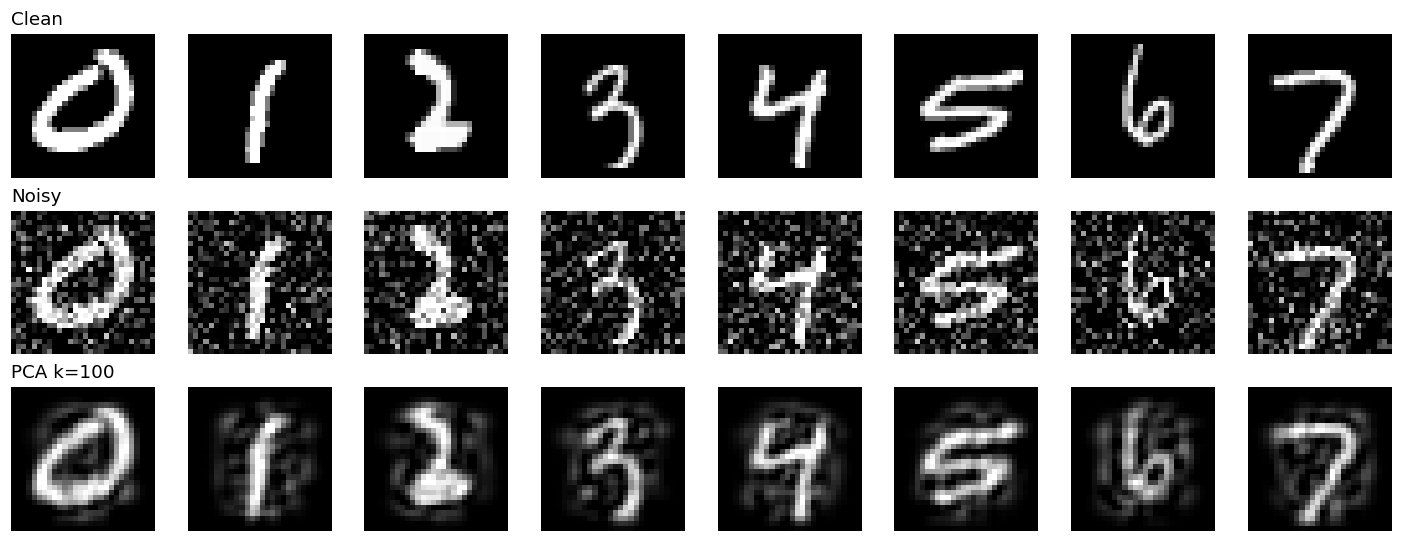

In [16]:
sigma = 0.3
rng = np.random.RandomState(0)
X_noisy = np.clip(X_test + rng.normal(0, sigma, X_test.shape), 0, 1).astype(np.float32)

dn_k = [2, 5, 10, 20, 30, 40, 50, 75, 100, 150, 200, 400, 784]
dn_mse = []
for k in dn_k:
    Xd = pca.inverse_transform(pca.transform(X_noisy, k), k)
    dn_mse.append(np.mean((X_test - Xd) ** 2))
baseline = np.mean((X_test - X_noisy) ** 2)
best_k = dn_k[int(np.argmin(dn_mse))]

plt.figure(figsize=(7, 4))
plt.plot(dn_k, dn_mse, "o-", label="PCA-denoised vs clean")
plt.axhline(baseline, color="r", ls="--", label=f"Noisy vs clean ({baseline:.4f})")
plt.axvline(best_k, color="g", ls=":", label=f"best k = {best_k}")
plt.xscale("log"); plt.xlabel("Number of components"); plt.ylabel("MSE to clean image")
plt.title(f"PCA denoising (σ = {sigma})"); plt.legend(); plt.show()

fig, axes = plt.subplots(3, 8, figsize=(13, 5))
Xd_best = pca.inverse_transform(pca.transform(X_noisy[sel], best_k), best_k)
for j in range(8):
    axes[0, j].imshow(X_test[sel[j]].reshape(28, 28), cmap="gray")
    axes[1, j].imshow(X_noisy[sel[j]].reshape(28, 28), cmap="gray")
    axes[2, j].imshow(np.clip(Xd_best[j], 0, 1).reshape(28, 28), cmap="gray")
    for r in range(3): axes[r, j].axis("off")
axes[0, 0].set_title("Clean", loc="left"); axes[1, 0].set_title("Noisy", loc="left"); axes[2, 0].set_title(f"PCA k={best_k}", loc="left")
plt.tight_layout(); plt.show()

## 8. Summary table

In [17]:
summary = rec.merge(clf[["k", "knn_acc", "logreg_acc"]], on="k", how="left")
summary["psnr"] = summary["psnr"].where(summary.k != 784)
summary = summary.rename(columns={
    "k": "Components", "mse": "Recon MSE", "psnr": "PSNR (dB)", "var_retained": "Variance kept",
    "compression": "Compression ×", "knn_acc": "KNN acc", "logreg_acc": "LogReg acc"})
summary.round(4).style.format(na_rep="–", precision=4)

,Components,Recon MSE,PSNR (dB),Variance kept,Compression ×,KNN acc,LogReg acc
0,1,0.0605,12.1840,0.0976,784.0000,–,–
1,2,0.0557,12.5421,0.1691,392.0000,0.4142,0.4392
2,3,0.0516,12.8776,0.2296,261.3333,–,–
3,5,0.0447,13.5012,0.3328,156.8000,0.7382,0.6772
4,10,0.0342,14.6635,0.4883,78.4000,0.9090,0.8030
5,15,0.0281,15.5153,0.5796,52.2667,–,–
6,20,0.0238,16.2304,0.6446,39.2000,0.9540,0.8700
7,30,0.0180,17.4447,0.7319,26.1333,0.9598,0.8870
8,40,0.0143,18.4407,0.7871,19.6000,–,–
9,50,0.0118,19.2966,0.8254,15.6800,0.9620,0.9000


## 9. Conclusions

- **Variance is concentrated.** Roughly 87 components keep 90 % of the variance, ~150 keep 95 %, and ~330 keep 99 % (exact numbers are in the table in section 4) — far below the 784 raw pixel dimensions.
- **Reconstruction improves with diminishing returns.** Error falls steeply for small $k$ and then flattens; digits are clearly readable from ≈ 30–50 components even though only about 70–80 % of the variance is retained.
- **Classification is robust to aggressive reduction.** KNN accuracy typically matches or even slightly beats the raw-pixel baseline at $k\approx 30$–$50$ while being much faster, because the discarded directions are mostly noise.
- **Denoising has a sweet spot.** Too small a $k$ removes signal, too large a $k$ lets noise back in, so the best $k$ for denoising is lower than the best $k$ for lossless reconstruction.
- **Limitation.** PCA is linear. Non-linear models (e.g. the autoencoder in the companion notebook) can capture curved structure and typically reconstruct/denoise better at the same code size.

**Ideas to extend:** try `IncrementalPCA` / randomized SVD on the full 70k set, kernel PCA, PCA whitening, or compare PCA vs. t-SNE/UMAP embeddings.